In [ ]:
!gdown https://drive.google.com/uc?id=1UevWzkl1EIPppg19LP3UuNHyrSm1OPjv

Downloading...
From (original): https://drive.google.com/uc?id=1UevWzkl1EIPppg19LP3UuNHyrSm1OPjv
From (redirected): https://drive.google.com/uc?id=1UevWzkl1EIPppg19LP3UuNHyrSm1OPjv&confirm=t&uuid=ac92e9a8-85b6-4ad3-9bc2-154348789964
To: /content/sampah (2).zip
100% 531M/531M [00:10<00:00, 49.4MB/s]


In [51]:
!unzip  "/content/sampah (2).zip"

In [52]:
!pip install split-folders
import splitfolders
import os
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [58]:
DATA_DIR = "Klasifikasi Sampah"

In [59]:
import os
import shutil

DATA_DIR = 'sampah/Klasifikasi Sampah'
NEW_DATA_DIR = 'Klasifikasi Sampah_flat'
os.makedirs(NEW_DATA_DIR, exist_ok=True)


categories = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print(f"Kategori: {categories}")

for cat in categories:
    cat_path = os.path.join(DATA_DIR, cat)
    new_cat_path = os.path.join(NEW_DATA_DIR, cat)
    os.makedirs(new_cat_path, exist_ok=True)

    copied = 0

    for root, dirs, files in os.walk(cat_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                src = os.path.join(root, file)
                dst = os.path.join(new_cat_path, file)


                if os.path.exists(dst):
                    name, ext = os.path.splitext(file)
                    subfolder_name = os.path.basename(root).replace(' ', '_')
                    dst = os.path.join(new_cat_path, f"{name}_{subfolder_name}{ext}")

                shutil.copy2(src, dst)
                copied += 1

    print(f"{cat}: {copied} gambar disalin ke {new_cat_path}")

Kategori: ['b3', 'organik', 'anorganik']
b3: 1962 gambar disalin ke Klasifikasi Sampah_flat/b3
organik: 476 gambar disalin ke Klasifikasi Sampah_flat/organik
anorganik: 4730 gambar disalin ke Klasifikasi Sampah_flat/anorganik


Jumlah kelas: 3
Nama kelas: ['anorganik', 'b3', 'organik']

anorganik: 4730 gambar
b3: 1962 gambar
organik: 476 gambar

Total gambar: 7168


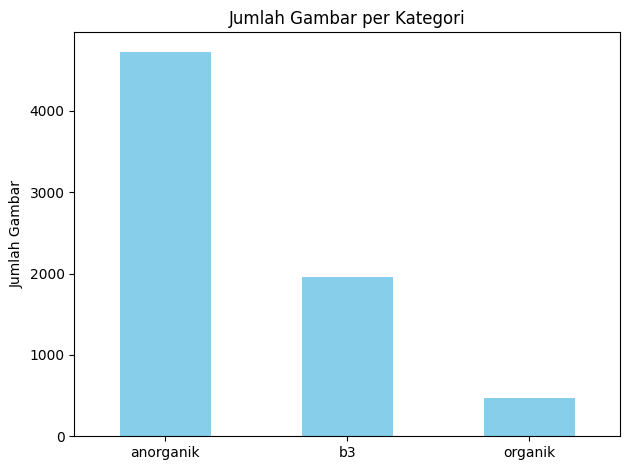


Rasio imbalance: 9.94x


In [60]:
NEW_DATA_DIR = 'Klasifikasi Sampah_flat'

classes = sorted(os.listdir(NEW_DATA_DIR))
print(f"Jumlah kelas: {len(classes)}")
print(f"Nama kelas: {classes}\n")

counts = {}
for cls in classes:
    cls_path = os.path.join(NEW_DATA_DIR, cls)
    num_images = len(os.listdir(cls_path))
    counts[cls] = num_images
    print(f"{cls}: {num_images} gambar")

total = sum(counts.values())
print(f"\nTotal gambar: {total}")

# Cek balance
import pandas as pd
import matplotlib.pyplot as plt

df = pd.Series(counts)
df.plot(kind='bar', title='Jumlah Gambar per Kategori', color='skyblue')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

max_count = df.max()
min_count = df.min()
print(f"\nRasio imbalance: {max_count/min_count:.2f}x")

In [61]:
DATA_DIR = 'Klasifikasi Sampah_flat'
OUTPUT_DIR = 'Klasifikasi Sampah_split'

splitfolders.ratio(
    DATA_DIR,
    output=OUTPUT_DIR,
    seed=42,
    ratio=(0.7, 0.15, 0.15)   # 70% train, 15% val, 15% test
)

print(f"\nSplit selesai!")

Copying files: 7168 files [00:04, 1706.48 files/s]


Split selesai!


In [62]:
import os

for split in ['train', 'val', 'test']:
    split_path = os.path.join(OUTPUT_DIR, split)
    print(f"\n📁 {split}/")
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        num_images = len(os.listdir(cls_path))
        print(f"  {cls}: {num_images} gambar")


📁 train/
  anorganik: 3311 gambar
  b3: 1373 gambar
  organik: 333 gambar

📁 val/
  anorganik: 709 gambar
  b3: 294 gambar
  organik: 71 gambar

📁 test/
  anorganik: 710 gambar
  b3: 295 gambar
  organik: 72 gambar


In [77]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_gen = train_datagen.flow_from_directory(
    'Klasifikasi Sampah_split/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

Found 5017 images belonging to 3 classes.


In [78]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_gen = val_datagen.flow_from_directory(
    'Klasifikasi Sampah_split/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1074 images belonging to 3 classes.


In [79]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    'Klasifikasi Sampah_split/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1077 images belonging to 3 classes.


In [80]:
print(f"Mapping kelas: {train_gen.class_indices}")
print(f"Train: {train_gen.samples} gambar")
print(f"Val: {val_gen.samples} gambar")
print(f"Test: {test_gen.samples} gambar")

Mapping kelas: {'anorganik': 0, 'b3': 1, 'organik': 2}
Train: 5017 gambar
Val: 1074 gambar
Test: 1077 gambar


In [81]:
IMG_SIZE = 128
NUM_CLASSES = train_gen.num_classes

model = models.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Conv Layer 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Conv Layer 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,963 (16.36 MB)

 Trainable params: 4,288,515 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [82]:
from tensorflow.keras.optimizers import Adam
LEARNING_RATE = 0.0001

model.compile(
    optimizer= Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [83]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [84]:
EPOCHS = 50

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/50
  8/157 ━━━━━━━━━━━━━━━━━━━━ 6:10 2s/step - accuracy: 0.4884 - loss: 2.2433

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 413s 3s/step - accuracy: 0.6805 - loss: 0.8979 - val_accuracy: 0.0661 - val_loss: 5.8218
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 405s 3s/step - accuracy: 0.7337 - loss: 0.5940 - val_accuracy: 0.6685 - val_loss: 1.7133
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 424s 3s/step - accuracy: 0.7377 - loss: 0.5836 - val_accuracy: 0.7588 - val_loss: 0.6484
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 405s 3s/step - accuracy: 0.7512 - loss: 0.5566 - val_accuracy: 0.7952 - val_loss: 0.4710
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 405s 3s/step - accuracy: 0.7556 - loss: 0.5347 - val_accuracy: 0.7980 - val_loss: 0.4664
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 400s 3s/step - accuracy: 0.7650 - loss: 0.5178 - val_accuracy: 0.8063 - val_loss: 0.4629
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accuracy: 0.7698 - loss: 0.5125 - val_accuracy: 0.8045 - val_loss: 0.4460
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 403s 3s/step - accuracy: 0.7786 - loss: 0.5039 - val_accuracy: 0.794

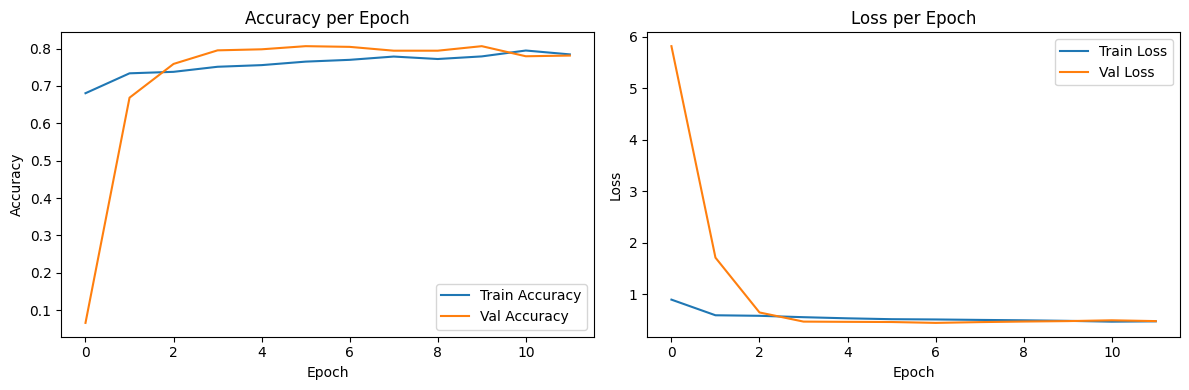

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Plot Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [86]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = test_gen.classes

y_pred_raw = model.predict(test_gen)
y_pred = np.argmax(y_pred_raw, axis=1)

class_names = list(train_gen.class_indices.keys())

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 620ms/step
Classification Report:
              precision    recall  f1-score   support

   anorganik       0.81      0.91      0.86       710
          b3       0.72      0.58      0.64       295
     organik       0.86      0.53      0.66        72

    accuracy                           0.79      1077
   macro avg       0.80      0.67      0.72      1077
weighted avg       0.79      0.79      0.79      1077



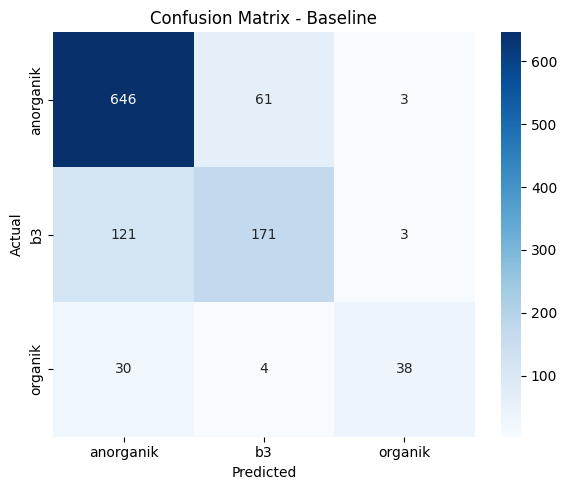

In [87]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Baseline')
plt.tight_layout()
plt.show()

Saving organik.jpg to organik (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
Gambar: organik (1).jpg
Prediksi: organik dengan keyakinan 0.46


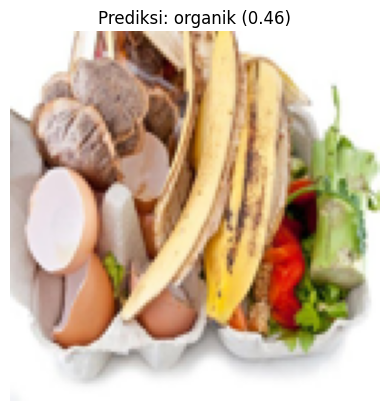

In [88]:
from google.colab import files
from tensorflow.keras.preprocessing import image


class_names = list(train_gen.class_indices.keys())

def predict_image(img_path, model, class_names, img_size=128):

    img = Image.open(img_path).convert('RGB')
    img = img.resize((img_size, img_size))


    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0


    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence = predictions[0][predicted_class_index]

    print(f"Gambar: {os.path.basename(img_path)}")
    print(f"Prediksi: {predicted_class_name} dengan keyakinan {confidence:.2f}")

    plt.imshow(img)
    plt.title(f"Prediksi: {predicted_class_name} ({confidence:.2f})")
    plt.axis('off')
    plt.show()


uploaded = files.upload()
img_path = list(uploaded.keys())[0]

predict_image(img_path, model, class_names, img_size=IMG_SIZE)

#**OUTPUT MINGGU KEDUA**

## Data Augmentasi + dropout + batch normalitation + tuning hyperparameter (menggunakan 5 kombinasi dari learning rate, batch size, dan epoch. hasil yang paling bagus dari 5 kombinasi ada pada eksperimen ke 3 dengan kombinasi learning rate = (0,0001) , batch size = 32 dan epoch 20).